## Creating the SEIR model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint 
print("complete")

complete


In [2]:
def seir_equations(y, t, N, beta, sigma, gamma):
    S, E, I, R = y 

    dS = -beta * S * I / N
    dE = beta * S * I / N - sigma * E
    dI = sigma * E - gamma * I
    dR = gamma * I 
    return [dS, dE, dI, dR]

## 1. SEIR Model Equations

The SEIR model extends SIR by adding an Exposed compartment.
σ (sigma) is the rate of progression from exposed to infectious — 
so 1/σ is the average incubation period.

For COVID-19, incubation period ≈ 5 days, so σ = 0.2

In [4]:
# Population and initial conditions
N = 67000000    # UK population
E0 = 100        # initially exposed
I0 = 10         # initially infectious
R0_init = 0     # initially recovered
S0 = N - E0 - I0 - R0_init

# Parameters
beta = 0.3      # transmission rate
sigma = 0.2     # incubation rate (1/5 days)
gamma = 0.1     # recovery rate (1/10 days)

# Time
t = np.linspace(0, 365, 1000)  # simulate one year

# Initial conditions vector
y0 = [S0, E0, I0, R0_init]

R0 = beta/gamma

print(R0)

2.9999999999999996


In [8]:
# Arrays to store results — start with initial values
S = np.zeros(len(t))
E = np.zeros(len(t))
I = np.zeros(len(t))
R = np.zeros(len(t))

S[0] = S0
E[0] = E0
I[0] = I0
R[0] = R0_init

dt = 366/1000

#Eulers loop
for i in range(1, len(t)):
    dS = -beta * S[i-1] * I[i-1] / N
    dE = beta * S[i-1] * I[i-1] / N - sigma * E[i-1] 
    dI = sigma * E[i-1] - gamma * I[i-1]
    dR = gamma * I[i-1]
    
    S[i] = S[i-1] + dS * dt
    E[i] = E[i-1] + dE * dt 
    I[i] = I[i-1] + dI * dt
    R[i] = R[i-1] + dR * dt

print(f'Simulation complete!')
print(f'Time steps: {len(t)}')
print(f'Final S: {S[-1]:.0f}')
print(f'Final E: {E[-1]:0f}')
print(f'Final I: {I[-1]:.0f}')
print(f'Final R: {R[-1]:.0f}')
print(f'Check N = S+E+I+R: {S[-1]+E[-1]+I[-1]+R[-1]:.0f}')

Simulation complete!
Time steps: 1000
Final S: 3888644
Final E: 0.518757
Final I: 4
Final R: 63111352
Check N = S+E+I+R: 67000000


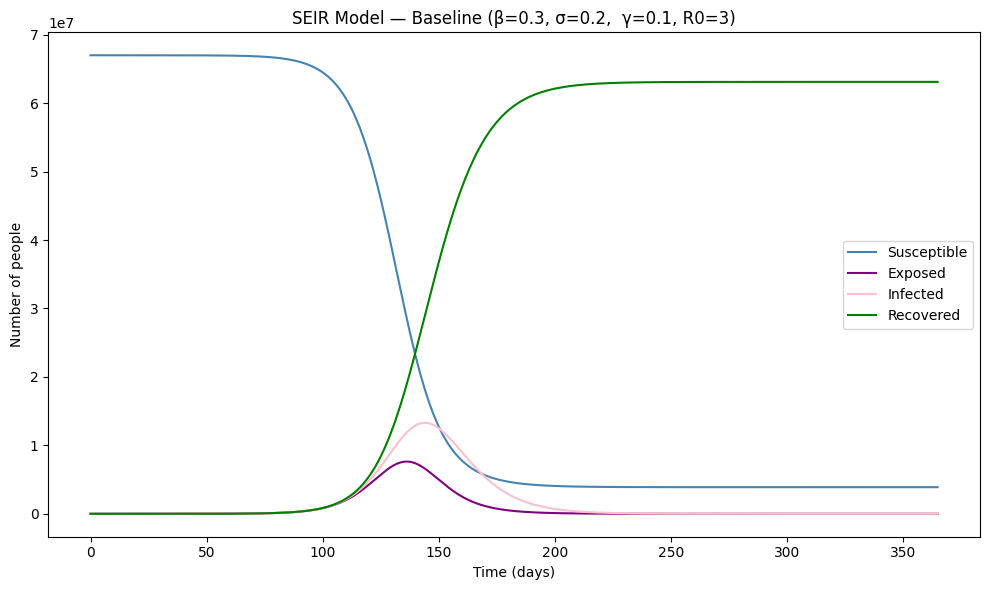

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='Susceptible', color='steelblue')
plt.plot(t, E, label='Exposed', color='purple')
plt.plot(t, I, label='Infected', color='pink')
plt.plot(t, R, label='Recovered', color='green')
plt.title('SEIR Model — Baseline (β=0.3, σ=0.2,  γ=0.1, R0=3)')
plt.xlabel('Time (days)')
plt.ylabel('Number of people')
plt.legend()
plt.tight_layout()
plt.show()

The exposed curve peaks slightly before the infected curve - this is the incubation period in action! The susceptable and recovered curves are mirror images of each other. 